# NB03 — Community composition response to warming (kraken2 taxonomy)

**Project**: Harvard Forest long-term warming, DNA vs RNA functional response

## Goal
Use kraken2 read-based taxonomy to test whether warming has changed community composition in the metagenome cohort (n=28 direct-sampled biosamples). This sets up the H1 baseline: how much DOES community turnover happen at +5°C?

## Tests
- Phylum-level relative abundance per sample
- PCoA on Bray-Curtis (genus level)
- PERMANOVA: composition ~ treatment + horizon (using `vegan`-style approach via scipy)
- Per-phylum t-test heated vs control

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import ttest_ind, false_discovery_control

DATA_DIR = os.path.abspath('../data')
FIG_DIR = os.path.abspath('../figures')

design = pd.read_csv(os.path.join(DATA_DIR, 'sample_design.tsv'), sep='\t')
kraken = pd.read_csv(os.path.join(DATA_DIR, 'kraken2_taxa_by_sample.tsv.gz'), sep='\t')

print(f'Design samples: {len(design)}')
print(f'Kraken2 samples: {kraken["biosample_id"].nunique()}')
print(f'Kraken rows: {len(kraken):,}')

Design samples: 42
Kraken2 samples: 28
Kraken rows: 189,465


## 1. Build the per-sample × phylum and per-sample × genus relative-abundance matrices

We use `clade_reads` (reads mapped at this clade level or below) and re-normalize within rank to make per-sample relative abundance.

In [2]:
def build_rank_matrix(df, rank_letter, min_total=0):
    sub = df[df['rank'] == rank_letter].copy()
    pivot = sub.pivot_table(index='biosample_id', columns='name',
                            values='clade_reads', aggfunc='sum', fill_value=0)
    # filter zero-total samples
    totals = pivot.sum(axis=1)
    keep = totals[totals > min_total].index
    pivot = pivot.loc[keep]
    relab = pivot.div(pivot.sum(axis=1), axis=0)
    return pivot, relab

phylum_counts, phylum_relab = build_rank_matrix(kraken, 'P')
genus_counts, genus_relab   = build_rank_matrix(kraken, 'G')
print(f'Phylum matrix: {phylum_relab.shape}')
print(f'Genus matrix:  {genus_relab.shape}')

Phylum matrix: (28, 43)
Genus matrix:  (28, 1622)


In [3]:
# Add design info
design_idx = design.set_index('biosample_id')
samples = phylum_relab.index
meta = design_idx.loc[samples, ['sample_name', 'treatment', 'horizon', 'incubated', 'plot']]
print(meta.groupby(['treatment', 'horizon']).size())

treatment  horizon
control    mineral    7
           organic    7
heated     mineral    7
           organic    7
dtype: int64


## 2. Top phyla and per-treatment differences

In [4]:
# Top 12 phyla by mean relative abundance
top_phyla = phylum_relab.mean().sort_values(ascending=False).head(12).index.tolist()
print('Top 12 phyla by mean relative abundance:')
print(phylum_relab[top_phyla].mean().round(4))

# Per-phylum mean by treatment, horizon (split at the (treat, horizon) cell)
df_long = phylum_relab[top_phyla].join(meta).melt(
    id_vars=['sample_name', 'treatment', 'horizon', 'incubated', 'plot'],
    var_name='phylum', value_name='relab')
by_cell = df_long.groupby(['treatment', 'horizon', 'phylum'])['relab'].mean().unstack('phylum').round(4)
print('\nMean relative abundance by treatment x horizon:')
print(by_cell)

Top 12 phyla by mean relative abundance:
name
Proteobacteria           0.6849
  Actinobacteria         0.2328
Acidobacteria            0.0273
    Bacteroidetes        0.0114
          Chordata       0.0098
  Firmicutes             0.0084
  Planctomycetes         0.0073
  Verrucomicrobia        0.0049
    Cyanobacteria        0.0030
  Deinococcus-Thermus    0.0023
Euryarchaeota            0.0014
  Gemmatimonadetes       0.0014
dtype: float64

Mean relative abundance by treatment x horizon:
phylum                       Chordata      Bacteroidetes      Cyanobacteria  \
treatment horizon                                                             
control   mineral              0.0071             0.0100             0.0033   
          organic              0.0118             0.0155             0.0032   
heated    mineral              0.0059             0.0081             0.0031   
          organic              0.0142             0.0121             0.0026   

phylum               Actinobact

In [5]:
# t-test heated vs control on top phyla, stratified by horizon
rows = []
for phy in top_phyla:
    for hz in ['organic', 'mineral']:
        cells = phylum_relab[phy].to_frame('rab').join(meta)
        cells = cells[cells['horizon'] == hz]
        c = cells.loc[cells['treatment'] == 'control', 'rab']
        h = cells.loc[cells['treatment'] == 'heated', 'rab']
        if len(c) >= 3 and len(h) >= 3:
            t = ttest_ind(h, c, equal_var=False)
            rows.append({
                'phylum': phy, 'horizon': hz,
                'mean_control': c.mean(), 'mean_heated': h.mean(),
                'log2_fc': np.log2((h.mean() + 1e-6) / (c.mean() + 1e-6)),
                't': t.statistic, 'p': t.pvalue,
                'n_control': len(c), 'n_heated': len(h),
            })
phylum_de = pd.DataFrame(rows)
if len(phylum_de):
    phylum_de['q'] = false_discovery_control(phylum_de['p'].values, method='bh')
phylum_de = phylum_de.sort_values('p')
print(phylum_de.head(15).to_string(index=False))

                     phylum horizon  mean_control  mean_heated   log2_fc         t        p  n_control  n_heated        q
             Actinobacteria organic      0.249015     0.315462  0.341233  3.977978 0.002592          7         7 0.049159
              Acidobacteria organic      0.034530     0.023597 -0.549230 -4.091467 0.004097          7         7 0.049159
              Cyanobacteria organic      0.003155     0.002553 -0.305212 -3.404247 0.009026          7         7 0.072211
             Proteobacteria organic      0.653674     0.605066 -0.111477 -2.937625 0.015153          7         7 0.088203
            Verrucomicrobia organic      0.005828     0.004084 -0.512883 -2.812943 0.018405          7         7 0.088203
           Gemmatimonadetes organic      0.001480     0.001247 -0.247672 -2.690040 0.025089          7         7 0.088203
                 Firmicutes organic      0.008644     0.007326 -0.238547 -2.659298 0.025726          7         7 0.088203
        Deinococcus-Ther

## 3. PCoA on Bray-Curtis (genus level)

In [6]:
def bray_curtis(X):
    return squareform(pdist(X.values, metric='braycurtis'))

def pcoa(D, k=4):
    n = D.shape[0]
    A = -0.5 * D ** 2
    H = np.eye(n) - np.ones((n, n)) / n
    B = H @ A @ H
    w, V = np.linalg.eigh(B)
    idx = np.argsort(-w)
    w = w[idx]
    V = V[:, idx]
    pos = w[:k].clip(min=0)
    coords = V[:, :k] * np.sqrt(pos)
    eigvals = w[:k]
    return coords, eigvals, w

D_genus = bray_curtis(genus_relab)
coords, eigvals, all_eig = pcoa(D_genus, k=4)
var_explained = eigvals.clip(min=0) / all_eig.clip(min=0).sum()
pc_df = pd.DataFrame(coords, index=genus_relab.index, columns=[f'PC{i+1}' for i in range(4)])
pc_df = pc_df.join(meta)
print(f'Variance explained: PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}, '
      f'PC3={var_explained[2]:.1%}, PC4={var_explained[3]:.1%}')
pc_df.head()

Variance explained: PC1=41.4%, PC2=29.3%, PC3=13.9%, PC4=4.7%


,PC1,PC2,PC3,PC4,sample_name,treatment,horizon,incubated,plot
biosample_id,,,,,,,,,
nmdc:bsm-11-042nd237,-0.017879,0.009211,-0.038988,0.018416,BW-C-7-M,control,mineral,False,7
nmdc:bsm-11-3p2mnz08,0.027238,0.035262,0.021861,0.014041,Inc-BW-H-2-O,heated,organic,True,2
nmdc:bsm-11-622k6044,-0.050127,-0.010233,-0.062843,0.009213,BW-C-12-M,control,mineral,False,12
nmdc:bsm-11-65a4xw75,-0.069623,0.022809,0.023880,-0.008937,BW-H-11-M,heated,mineral,False,11
nmdc:bsm-11-6m6c9g55,0.093599,0.030509,0.058501,-0.038607,Inc-BW-H-11-O,heated,organic,True,11


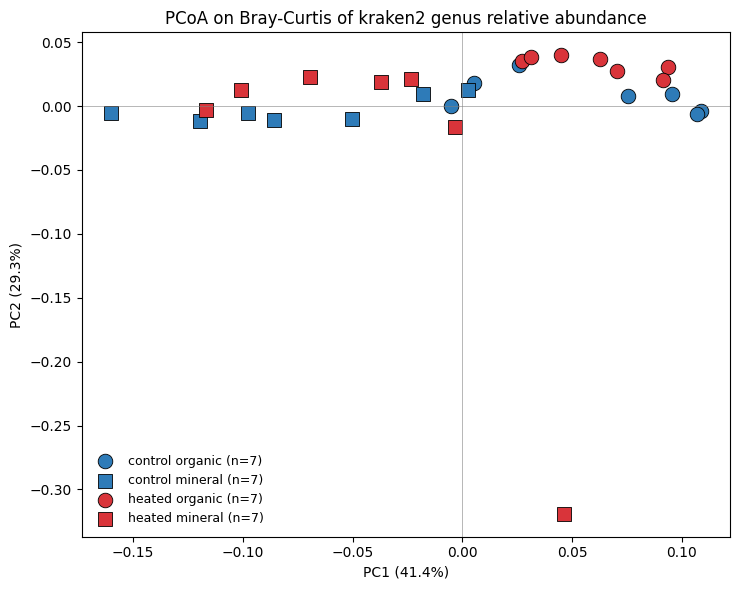

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/03_taxa_pcoa.png


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 6))
color_map = {'control': '#2e7bb8', 'heated': '#d9343a'}
marker_map = {'organic': 'o', 'mineral': 's'}
for tx in ['control', 'heated']:
    for hz in ['organic', 'mineral']:
        sub = pc_df[(pc_df['treatment'] == tx) & (pc_df['horizon'] == hz)]
        ax.scatter(sub['PC1'], sub['PC2'], c=color_map[tx], marker=marker_map[hz],
                    s=110, edgecolors='black', linewidths=0.6,
                    label=f'{tx} {hz} (n={len(sub)})')
ax.set_xlabel(f'PC1 ({var_explained[0]:.1%})')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1%})')
ax.set_title('PCoA on Bray-Curtis of kraken2 genus relative abundance')
ax.legend(frameon=False, fontsize=9)
ax.axhline(0, color='gray', linewidth=0.4)
ax.axvline(0, color='gray', linewidth=0.4)
plt.tight_layout()
out = os.path.join(FIG_DIR, '03_taxa_pcoa.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Wrote {out}')

## 4. PERMANOVA: composition ~ treatment + horizon

Implement a simple PERMANOVA (Anderson 2001). Pseudo-F obtained from sum of squared distances; p-value via 9999 permutations of group labels.

In [8]:
def permanova(D, groups, n_perm=9999, seed=42):
    """PERMANOVA F statistic + permutation p-value (Anderson 2001).

    D: square distance matrix (n x n)
    groups: 1D array of categorical labels (length n)
    """
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    g = pd.Series(groups, dtype='category')
    levels = g.cat.categories
    a = len(levels)
    SS_T = (D ** 2).sum() / (2 * n)
    def ss_within(labels):
        s = 0.0
        for L in levels:
            idx = np.where(labels == L)[0]
            if len(idx) > 1:
                Dsub = D[np.ix_(idx, idx)]
                s += (Dsub ** 2).sum() / (2 * len(idx))
        return s
    SS_W = ss_within(g.values)
    SS_A = SS_T - SS_W
    F = (SS_A / (a - 1)) / (SS_W / (n - a))
    R2 = SS_A / SS_T
    perm_F = np.empty(n_perm)
    labels_arr = np.asarray(g.values)
    for k in range(n_perm):
        perm = rng.permutation(labels_arr)
        SS_W_p = ss_within(perm)
        SS_A_p = SS_T - SS_W_p
        perm_F[k] = (SS_A_p / (a - 1)) / (SS_W_p / (n - a))
    p_value = (np.sum(perm_F >= F) + 1) / (n_perm + 1)
    return F, p_value, R2

# Marginal tests
F_t, p_t, R2_t = permanova(D_genus, meta['treatment'].values, n_perm=4999)
F_h, p_h, R2_h = permanova(D_genus, meta['horizon'].values, n_perm=4999)
F_c, p_c, R2_c = permanova(D_genus, (meta['treatment'] + '_' + meta['horizon']).values, n_perm=4999)
perm_results = pd.DataFrame([
    {'factor': 'treatment',          'F': F_t, 'R2': R2_t, 'p': p_t},
    {'factor': 'horizon',            'F': F_h, 'R2': R2_h, 'p': p_h},
    {'factor': 'treatment_x_horizon', 'F': F_c, 'R2': R2_c, 'p': p_c},
])
print(perm_results.to_string(index=False))

             factor         F       R2      p
          treatment  2.126206 0.075595 0.0694
            horizon 11.473449 0.306175 0.0002
treatment_x_horizon  5.560634 0.410057 0.0002


## 5. Phylum stacked bar plot (treatment x horizon)

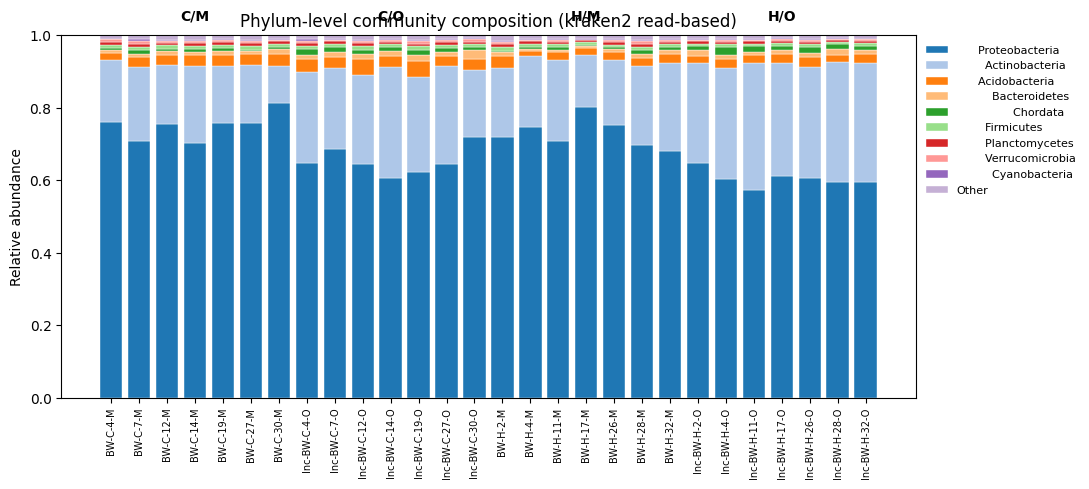

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/03_phylum_bars.png


In [9]:
# Top 9 phyla, lump the rest into 'Other'
top9 = phylum_relab.mean().sort_values(ascending=False).head(9).index.tolist()
stack = phylum_relab[top9].copy()
stack['Other'] = 1.0 - stack.sum(axis=1)
stack = stack.join(meta).sort_values(['treatment', 'horizon', 'plot'])
phyla_order = top9 + ['Other']

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(stack))
cmap = plt.cm.tab20
x = np.arange(len(stack))
for i, phy in enumerate(phyla_order):
    ax.bar(x, stack[phy].values, bottom=bottom, color=cmap(i), label=phy, edgecolor='white', linewidth=0.3)
    bottom += stack[phy].values
labels = [f"{r['sample_name']}" for _, r in stack.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('Relative abundance')
ax.set_title('Phylum-level community composition (kraken2 read-based)')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=8)
ax.set_ylim(0, 1)
# Treatment / horizon group spans
for hz in ['mineral', 'organic']:
    for tx in ['control', 'heated']:
        idx = stack.index[(stack['treatment'] == tx) & (stack['horizon'] == hz)]
        if len(idx):
            pos = [stack.index.get_loc(i) for i in idx]
            mid = sum(pos) / len(pos)
            ax.text(mid, 1.04, f'{tx[0].upper()}/{hz[0].upper()}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
out = os.path.join(FIG_DIR, '03_phylum_bars.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Wrote {out}')

## 6. Save tabular outputs

In [10]:
out_pcoa = os.path.join(DATA_DIR, '03_pcoa_genus.tsv')
pc_df.to_csv(out_pcoa, sep='\t')
print(f'Wrote {out_pcoa}')

out_perm = os.path.join(DATA_DIR, '03_permanova_results.tsv')
perm_results.to_csv(out_perm, sep='\t', index=False)
print(f'Wrote {out_perm}')

out_de = os.path.join(DATA_DIR, '03_phylum_treatment_tests.tsv')
phylum_de.to_csv(out_de, sep='\t', index=False)
print(f'Wrote {out_de}')

phylum_path = os.path.join(DATA_DIR, '03_phylum_relab.tsv')
phylum_relab.to_csv(phylum_path, sep='\t')
print(f'Wrote {phylum_path}')

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/data/03_pcoa_genus.tsv
Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/data/03_permanova_results.tsv
Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/data/03_phylum_treatment_tests.tsv
Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/data/03_phylum_relab.tsv


## 7. Summary

- Community composition assessed at phylum and genus level using kraken2 read-based taxonomy on n=28 metagenome samples (no metatranscriptome here — we'll use those for functional analyses in NB04).
- PERMANOVA tests treatment, horizon, and joint (4-cell) factor explaining genus-level Bray-Curtis variance.
- Per-phylum t-tests stratified by horizon report which phyla shift between heated and control.